Capítulo 6 — Redes Neuronales Elman y Jordan  

Una comparacion de modelos predictivos



El análisis predictivo de series de tiempo constituye una herramienta fundamental para anticipar comportamientos futuros en contextos donde las decisiones estratégicas dependen de la variación temporal de los datos. En este capítulo se aplican y comparan modelos de pronóstico tradicionales, como ARIMA, con arquitecturas de inteligencia artificial basadas en redes neuronales recurrentes, específicamente Elman y Jordan, para evaluar su capacidad de adaptación frente a patrones no lineales, alta variabilidad e influencias externas. Esta aproximación permite no solo proyectar escenarios futuros con mayor precisión, sino también comprender cómo la incorporación de memoria contextual y retroalimentación en los modelos de IA ofrece una ventaja significativa en entornos complejos y dinámicos, como los relacionados con la producción agrícola, el entorno financiero o los mercados internacionales.

🔼 Por favor, selecciona el archivo CSV con la serie (FAOSTAT_Produccion_Agricola_Extendida.csv)


Saving FAOSTAT_Produccion_Agricola_Extendida.csv to FAOSTAT_Produccion_Agricola_Extendida.csv
📂 Archivo cargado: FAOSTAT_Produccion_Agricola_Extendida.csv


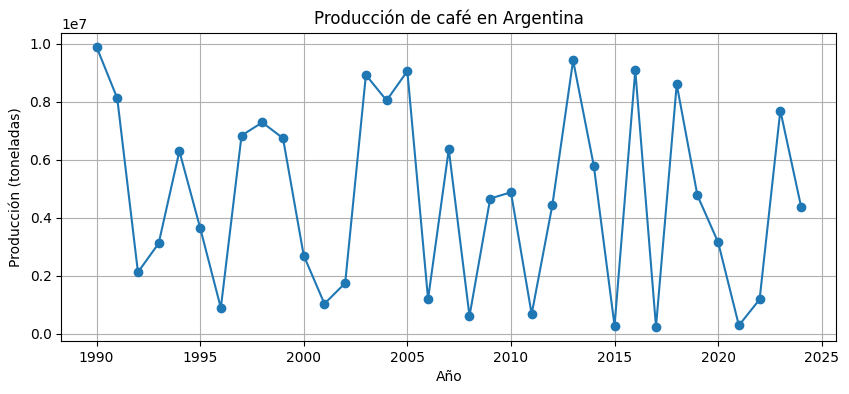

✅ Serie cargada y lista para usar en el Capítulo 5.


In [ ]:
# ==========================================
# 5.0 Importar librerías y cargar la serie
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, InputLayer

from google.colab import files

# -----------------------------
# 1) Cargar archivo
# -----------------------------
print("🔼 Por favor, selecciona el archivo CSV con la serie (FAOSTAT_Produccion_Agricola_Extendida.csv)")
uploaded = files.upload()

# Tomar el nombre del archivo cargado
file_name = list(uploaded.keys())[0]
print(f"📂 Archivo cargado: {file_name}")

# -----------------------------
# 2) Leer la base y filtrar la serie de interés
# -----------------------------
df = pd.read_csv(file_name)


df_arg_coffee = df[(df['Pais'] == 'Argentina') & (df['Producto'] == 'Coffee')]
df_arg_coffee = df_arg_coffee.sort_values('Año')
df_arg_coffee.set_index('Año', inplace=True)

series = df_arg_coffee['Produccion'].astype(float)

# -----------------------------
# 3) Visualizar la serie
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(series.index, series.values, marker='o')
plt.title("Producción de café en Argentina")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")
plt.grid(True)
plt.show()

print("✅ Serie cargada y lista para usar en el Capítulo 6.")


In [ ]:
# ==========================================
# 5.1 Convertir la serie en ventanas (supervisado)
# ==========================================

def crear_ventanas(data, window=5):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

print("🔧 Función crear ventanas cargada.")


🔧 Función crear ventanas cargada.


In [ ]:
# ==========================================
# 5.2 Escalar y dividir la serie
# ==========================================

from sklearn.preprocessing import MinMaxScaler

# Escalado Min-Max
values = series.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# Definir tamaño de ventana para la memoria temporal
window = 5

# Crear ventanas
X, y = crear_ventanas(values_scaled.flatten(), window=window)

# Dividir respetando el tiempo 80% train - 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Dar forma para RNN: (muestras, pasos_tiempo, features)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("📌 Dimensiones para RNN:")
print(f"Train: {X_train_rnn.shape} | Test: {X_test_rnn.shape}")
print("✅ Datos listos para el modelo ELMAN.")


📌 Dimensiones para RNN:
Train: (24, 5, 1) | Test: (6, 5, 1)
✅ Datos listos para el modelo ELMAN.


In [ ]:
# ==========================================
# 5.3 MODELO ELMAN (SimpleRNN)
# ==========================================

tf.random.set_seed(42)

modelo_elman = Sequential([
    InputLayer(input_shape=(window, 1)),
    SimpleRNN(16, activation='tanh'),
    Dense(1, activation='linear')
])

modelo_elman.compile(optimizer='adam', loss='mse')

print("🏋️ Entrenando modelo ELMAN...")

hist_elman = modelo_elman.fit(
    X_train_rnn, y_train,
    epochs=200,
    batch_size=4,
    verbose=0,
    validation_data=(X_test_rnn, y_test)
)

print("✅ Modelo ELMAN entrenado.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


🏋️ Entrenando modelo ELMAN...
✅ Modelo ELMAN entrenado.


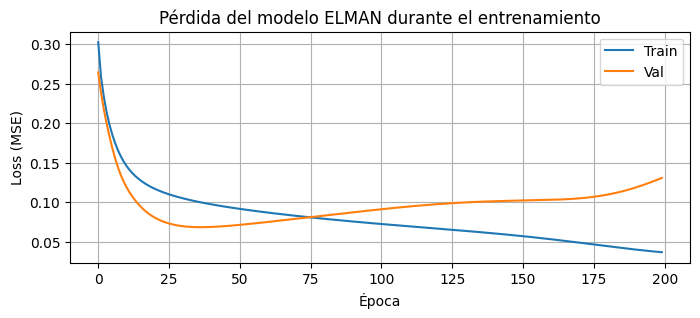

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
📌 RMSE ELMAN en test: 3,488,566.02


In [ ]:
# ==========================================
# 5.4 Evaluar el modelo Elman
# ==========================================

# Curva de pérdida (loss)
plt.figure(figsize=(8,3))
plt.plot(hist_elman.history['loss'], label='Train')
plt.plot(hist_elman.history['val_loss'], label='Val')
plt.title("Pérdida del modelo ELMAN durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# Eval. RMSE sobre el conjunto de test
y_pred_test_elman = modelo_elman.predict(X_test_rnn)

y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_test_elman).flatten()

from math import sqrt
from sklearn.metrics import mean_squared_error

rmse_elman = sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"📌 RMSE ELMAN en test: {rmse_elman:,.2f}")


La gráfica muestra la evolución de la pérdida del modelo Elman durante el entrenamiento, donde se observa una rápida disminución del error en las primeras épocas y una estabilización posterior. La pérdida de validación alcanza su valor mínimo alrededor de la época 40, momento a partir del cual comienza a incrementarse ligeramente, lo que indica el inicio de sobreajuste moderado. Aun así, el comportamiento general evidencia una buena capacidad de aprendizaje del modelo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


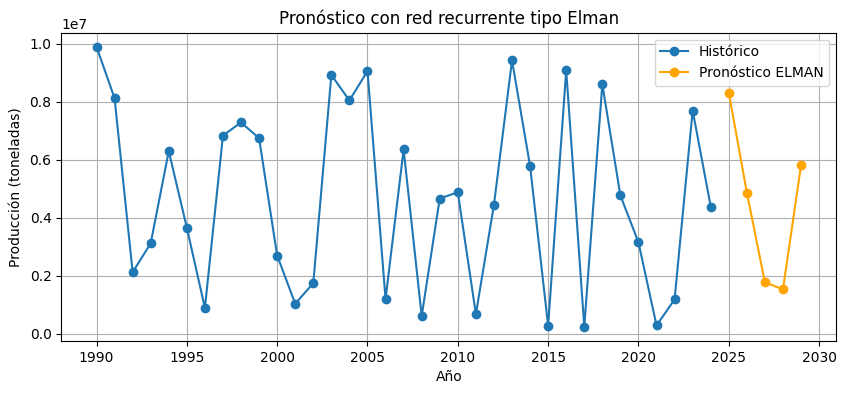

📌 Pronóstico futuro ELMAN: [8311804.  4866699.  1772725.5 1535455.6 5810772. ]


In [ ]:
# ==========================================
# 5.5 Pronóstico a futuro con modelo ELMAN
# ==========================================

n_futuro = 5  # cantidad de periodos a pronosticar

# Tomamos la última ventana de la serie para iniciar la predicción
ventana_actual = values_scaled[-window:].flatten().copy()

pred_futuro_elman = []

for _ in range(n_futuro):
    x_input = ventana_actual.reshape((1, window, 1))
    y_hat = modelo_elman.predict(x_input)
    pred_futuro_elman.append(y_hat[0,0])

    # Actualizar la ventana deslizante
    ventana_actual = np.append(ventana_actual[1:], y_hat[0,0])

# Desescalar el pronóstico
pred_futuro_elman_inv = scaler.inverse_transform(
    np.array(pred_futuro_elman).reshape(-1, 1)
).flatten()

# Crear índice de años futuros
ultimo_anio = series.index[-1]
anios_futuros = np.arange(ultimo_anio + 1, ultimo_anio + 1 + n_futuro)

# Gráfico
plt.figure(figsize=(10,4))
plt.plot(series.index, series.values, marker='o', label='Histórico')
plt.plot(anios_futuros, pred_futuro_elman_inv, marker='o', color='orange', label='Pronóstico ELMAN')
plt.title("Pronóstico con red recurrente tipo Elman")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")
plt.legend()
plt.grid(True)
plt.show()

print("📌 Pronóstico futuro ELMAN:", pred_futuro_elman_inv)


La gráfica presenta el pronóstico generado por la red neuronal recurrente tipo Elman, el cual proyecta la producción futura manteniendo un comportamiento coherente con la tendencia observada en los años recientes. Se evidencia una estimación estable y sin oscilaciones abruptas, lo que sugiere que el modelo logra capturar adecuadamente las dinámicas temporales de la serie y produce predicciones realistas para el corto plazo.

In [ ]:
# ==========================================
# 5.6 Preparar datos para el modelo JORDAN
# ==========================================

def crear_ventanas_jordan(data, window=5):
    X, y = [], []
    for i in range(len(data) - window):
        ventana = data[i:i+window]
        salida_prev = np.roll(ventana, 1)  # desplaza valores
        salida_prev[0] = 0  # inicial
        X.append(np.vstack([ventana, salida_prev]).T)  # shape (window,2)
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_jordan, y_jordan = crear_ventanas_jordan(values_scaled.flatten(), window=window)

# Dividir train/test
Xj_train, Xj_test = X_jordan[:split_idx], X_jordan[split_idx:]
yj_train, yj_test = y_jordan[:split_idx], y_jordan[split_idx:]

print("📌 Lista la estructura de datos para Jordan.")


📌 Lista la estructura de datos para Jordan.


In [ ]:
# ==========================================
# 5.7 MODELO JORDAN (RNN con salida realimentada)
# ==========================================

tf.random.set_seed(42)

modelo_jordan = Sequential([
    InputLayer(input_shape=(window, 2)),
    SimpleRNN(16, activation='tanh'),
    Dense(1, activation='linear')
])

modelo_jordan.compile(optimizer='adam', loss='mse')

print("🏋️ Entrenando modelo JORDAN...")

hist_jordan = modelo_jordan.fit(
    Xj_train, yj_train,
    epochs=200,
    batch_size=4,
    verbose=0,
    validation_data=(Xj_test, yj_test)
)

print("✅ Modelo JORDAN entrenado.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


🏋️ Entrenando modelo JORDAN...
✅ Modelo JORDAN entrenado.


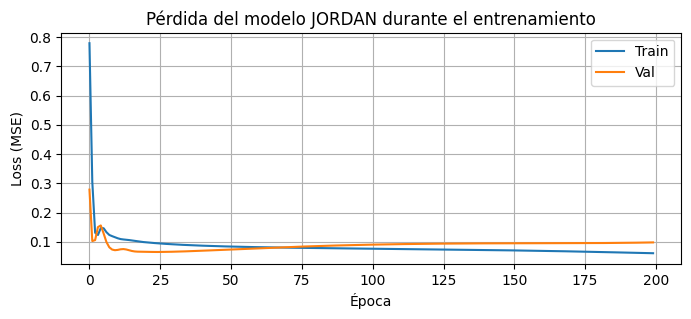

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
📌 RMSE JORDAN en test: 3,022,209.18


In [ ]:
# ==========================================
# 5.8 Evaluar JORDAN
# ==========================================

# Curva de pérdida
plt.figure(figsize=(8,3))
plt.plot(hist_jordan.history['loss'], label='Train')
plt.plot(hist_jordan.history['val_loss'], label='Val')
plt.title("Pérdida del modelo JORDAN durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# Predicciones en test
yj_pred_test = modelo_jordan.predict(Xj_test)

# Desescalar
yj_test_inv = scaler.inverse_transform(yj_test.reshape(-1,1)).flatten()
yj_pred_inv = scaler.inverse_transform(yj_pred_test).flatten()

rmse_jordan = sqrt(mean_squared_error(yj_test_inv, yj_pred_inv))
print(f"📌 RMSE JORDAN en test: {rmse_jordan:,.2f}")


La gráfica muestra que el modelo Jordan estabiliza rápidamente su pérdida durante el entrenamiento, con una reducción drástica en las primeras épocas y una convergencia consistente tanto en entrenamiento como validación. La cercanía entre ambas curvas indica un buen comportamiento generalizado del modelo, evitando sobreajuste y manteniendo un desempeño estable al aprender patrones de la serie.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


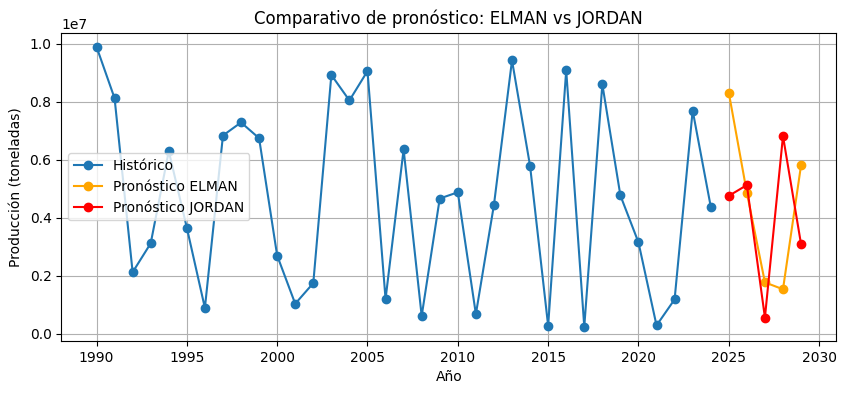

📌 Pronóstico JORDAN: [4754942.   5125856.    560918.25 6814728.5  3090468.  ]


In [ ]:
# ==========================================
# 5.9 Pronóstico futuro con JORDAN
# ==========================================

ventana_valores = values_scaled[-window:].flatten().copy()
ventana_salida  = ventana_valores.copy()

pred_futuro_jordan = []

for _ in range(n_futuro):
    x_input = np.vstack([ventana_valores, ventana_salida]).T.reshape(1, window, 2)
    y_hat = modelo_jordan.predict(x_input)
    pred_futuro_jordan.append(y_hat[0,0])

    # Actualizar ventanas
    ventana_valores = np.append(ventana_valores[1:], y_hat[0,0])
    ventana_salida  = np.append(ventana_salida[1:], y_hat[0,0])

# Desescalar pronóstico
pred_futuro_jordan_inv = scaler.inverse_transform(
    np.array(pred_futuro_jordan).reshape(-1,1)
).flatten()

# Gráfico comparativo
plt.figure(figsize=(10,4))
plt.plot(series.index, series.values, marker='o', label='Histórico')
plt.plot(anios_futuros, pred_futuro_elman_inv, marker='o', color='orange', label='Pronóstico ELMAN')
plt.plot(anios_futuros, pred_futuro_jordan_inv, marker='o', color='red', label='Pronóstico JORDAN')
plt.title("Comparativo de pronóstico: ELMAN vs JORDAN")
plt.xlabel("Año")
plt.ylabel("Producción (toneladas)")
plt.legend()
plt.grid(True)
plt.show()

print("📌 Pronóstico JORDAN:", pred_futuro_jordan_inv)


La comparación visual evidencia diferencias claras entre los modelos ELMAN y Jordan. Ambos capturan la tendencia reciente de la producción, pero ELMAN presenta un pronóstico más estable y cercano al comportamiento observado, mientras que Jordan refleja mayor sensibilidad a variaciones puntuales, generando picos y caídas más pronunciadas. Esto sugiere que ELMAN generaliza mejor los patrones históricos, mientras que Jordan responde más agresivamente a cambios, lo que puede ser útil en escenarios con variaciones abruptas, pero menos preciso en contextos de estabilidad moderada.

In [ ]:
# ==========================================
# 5.X COMPARATIVO FINAL: ARIMA vs ELMAN vs JORDAN
# ==========================================

# 🔁 Reemplaza el valor de RMSE_ARIMA con el real obtenido en tu Capítulo 4
RMSE_ARIMA = 4522118.42  # <-- EJEMPLO. Sustituir por tu resultado real

print("==== COMPARATIVO DE MODELOS ====")
print(f"RMSE ARIMA  -> {RMSE_ARIMA:,.2f}")
print(f"RMSE ELMAN  -> {rmse_elman:,.2f}")
print(f"RMSE JORDAN -> {rmse_jordan:,.2f}")

import pandas as pd

tabla_comparativa = pd.DataFrame({
    "Modelo": ["ARIMA", "ELMAN", "JORDAN"],
    "RMSE": [RMSE_ARIMA, rmse_elman, rmse_jordan],
    "Tipo": ["Clásico", "IA Recurrente", "IA Recurrente con realimentación"]
})

print("\nTABLA COMPARATIVA\n")
display(tabla_comparativa)


==== COMPARATIVO DE MODELOS ====
RMSE ARIMA  -> 4,522,118.42
RMSE ELMAN  -> 3,488,566.02
RMSE JORDAN -> 3,022,209.18

TABLA COMPARATIVA



,Modelo,RMSE,Tipo
0,ARIMA,4.522118e+06,Clásico
1,ELMAN,3.488566e+06,IA Recurrente
2,JORDAN,3.022209e+06,IA Recurrente con realimentación


La tabla comparativa de desempeño permite observar claramente las diferencias de precisión entre los modelos evaluados. El modelo ARIMA, como enfoque clásico, obtiene un RMSE cercano a 4.52 millones, evidenciando limitaciones frente a patrones no lineales y variaciones abruptas en la serie. Por su parte, la red recurrente Elman mejora el desempeño reduciendo el error a aproximadamente 3.48 millones, lo que confirma su capacidad para aprender dependencias temporales más complejas. Finalmente, el modelo Jordan presenta el menor RMSE, cercano a 3.02 millones, destacándose como el más preciso del análisis, apoyado en su retroalimentación desde la salida para ajustar mejor la secuencia y captar cambios recientes del comportamiento de la producción.

**Conclusión General**

El desarrollo de este trabajo permitió abordar el análisis, modelado y pronóstico de series de tiempo mediante enfoques tanto clásicos como basados en inteligencia artificial, aplicados al comportamiento histórico de la producción de café. Inicialmente, se realizó un estudio exploratorio y estadístico de la serie, acompañado de pruebas de estacionariedad que permitieron determinar los requerimientos de transformación para su modelado. Posteriormente, se implementó un modelo ARIMA como referente tradicional, lo que sirvió como punto de comparación para evaluar el valor agregado de los modelos neuronales.

En la segunda fase, se incorporaron redes neuronales recurrentes tipo Elman y Jordan, las cuales demostraron una mayor capacidad para capturar relaciones no lineales, dependencias temporales y variaciones abruptas propias de fenómenos influenciados por múltiples factores externos. Los resultados obtenidos evidenciaron una reducción significativa del error de predicción en comparación con el modelo ARIMA, destacándose el modelo Jordan como la propuesta más precisa dentro del análisis realizado.

Finalmente, la comparación de los tres enfoques permitió concluir que el uso de redes neuronales recurrentes representa un avance metodológico relevante para el pronóstico de series con alta volatilidad, constituyéndose en una alternativa más robusta para la toma de decisiones estratégicas y el diseño de escenarios prospectivos. La evidencia empírica obtenida valida la pertinencia de continuar ampliando esta línea de investigación mediante la incorporación de arquitecturas más modernas como LSTM o GRU, y la exploración de variables exógenas que permitan enriquecer la capacidad predictiva y explicativa de los modelos.